In [21]:
#only loss graph is only needed to be plotted, accuracy graph is not needed. So, I have removed the code for plotting accuracy graph and kept only the code for plotting loss graph.

In [22]:
from warnings import filterwarnings
filterwarnings('ignore')

In [23]:
from warnings import filterwarnings
filterwarnings('ignore')

import numpy as np
import pandas as pd 
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.layers import Dense, SimpleRNN, LSTM, Dropout, Embedding
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split


In [24]:
#sample dataset
corpus = [
    "I love machine learning",
    "LSTM networks are powerful for sequence data",
    "RNNs can capture temporal dependencies",
    "Deep learning is revolutionizing AI",
    "Natural language processing is fascinating",
    "I enjoy coding in Python",
    "Neural networks can approximate complex functions",
    "Recurrent layers help with time series data",
    "Natural language processing is a key area of AI",
]

#Tokenize the text
tokenizer = Tokenizer()
tokenizer.fit_on_texts(corpus)
total_words = len(tokenizer.word_index) + 1 #+1 added to accommodate for padding token
print("Total unique words:", total_words)
# print("\n--------------------------------------------------------------\n")
    
#create input sequence and labels
input_sequences_unpadded = []
for line in corpus:
    token_list = tokenizer.texts_to_sequences([line])[0] #convert the input text to a sequence of integers
    for i in range(1, len(token_list)):
        n_gram_sequence = token_list[:i+1]
        # print("n-gram sequence:", n_gram_sequence)
        input_sequences_unpadded.append(n_gram_sequence)

print("Total input sequences:", len(input_sequences_unpadded))
# print("\n--------------------------------------------------------------\n")

#pad sequences
max_sequence_len = max([len(x) for x in input_sequences_unpadded])
input_sequences_padded = pad_sequences(input_sequences_unpadded, maxlen=max_sequence_len, padding='pre')
# print("Padded input sequences:\n", input_sequences_padded)
# print("\n--------------------------------------------------------------\n")

import pandas as pd

df = pd.DataFrame({
    'Unpadded Sequences': [str(seq) for seq in input_sequences_unpadded],
    'Padded Sequences': [str(seq) for seq in input_sequences_padded]
})
print(df.to_string(index=False))

#create features and labels
x,y = input_sequences_padded[:,:-1],input_sequences_padded[:,-1]
y = tf.keras.utils.to_categorical(y,num_classes=total_words)

Total unique words: 43
Total input sequences: 44
              Unpadded Sequences             Padded Sequences
                         [2, 11] [ 0  0  0  0  0  0  0  2 11]
                     [2, 11, 12] [ 0  0  0  0  0  0  2 11 12]
                  [2, 11, 12, 3] [ 0  0  0  0  0  2 11 12  3]
                         [13, 4] [ 0  0  0  0  0  0  0 13  4]
                     [13, 4, 14] [ 0  0  0  0  0  0 13  4 14]
                 [13, 4, 14, 15] [ 0  0  0  0  0 13  4 14 15]
             [13, 4, 14, 15, 16] [ 0  0  0  0 13  4 14 15 16]
         [13, 4, 14, 15, 16, 17] [ 0  0  0 13  4 14 15 16 17]
      [13, 4, 14, 15, 16, 17, 5] [ 0  0 13  4 14 15 16 17  5]
                         [18, 6] [ 0  0  0  0  0  0  0 18  6]
                     [18, 6, 19] [ 0  0  0  0  0  0 18  6 19]
                 [18, 6, 19, 20] [ 0  0  0  0  0 18  6 19 20]
             [18, 6, 19, 20, 21] [ 0  0  0  0 18  6 19 20 21]
                         [22, 3] [ 0  0  0  0  0  0  0 22  3]
                     

In [25]:
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [26]:
from warnings import filterwarnings
filterwarnings('ignore')
model=Sequential()
model.add(Embedding(total_words, 100, input_length=max_sequence_len-1))
model.add(LSTM(150))
model.add(Dropout(0.2))
model.add(Dense(total_words, activation='softmax'))
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])


In [27]:
model.summary()

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding_2 (Embedding)     (None, 8, 100)            4300      
                                                                 
 lstm_2 (LSTM)               (None, 150)               150600    
                                                                 
 dropout_2 (Dropout)         (None, 150)               0         
                                                                 
 dense_2 (Dense)             (None, 43)                6493      
                                                                 
Total params: 161393 (630.44 KB)
Trainable params: 161393 (630.44 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [28]:
from warnings import filterwarnings
filterwarnings('ignore')
history=model.fit(X_train, y_train, epochs=120, validation_data=(X_test, y_test), verbose=1)

Epoch 1/120
2/2 [==============================] - 3s 535ms/step - loss: 3.7614 - accuracy: 0.0286 - val_loss: 3.7589 - val_accuracy: 0.1111
Epoch 2/120
2/2 [==============================] - 0s 48ms/step - loss: 3.7532 - accuracy: 0.0571 - val_loss: 3.7599 - val_accuracy: 0.0000e+00
Epoch 3/120
2/2 [==============================] - 0s 44ms/step - loss: 3.7426 - accuracy: 0.1143 - val_loss: 3.7624 - val_accuracy: 0.0000e+00
Epoch 4/120
2/2 [==============================] - 0s 41ms/step - loss: 3.7309 - accuracy: 0.2000 - val_loss: 3.7652 - val_accuracy: 0.0000e+00
Epoch 5/120
2/2 [==============================] - 0s 42ms/step - loss: 3.7246 - accuracy: 0.1714 - val_loss: 3.7686 - val_accuracy: 0.0000e+00
Epoch 6/120
2/2 [==============================] - 0s 44ms/step - loss: 3.7161 - accuracy: 0.1714 - val_loss: 3.7732 - val_accuracy: 0.0000e+00
Epoch 7/120
2/2 [==============================] - 0s 40ms/step - loss: 3.6988 - accuracy: 0.1429 - val_loss: 3.7793 - val_accuracy: 0.0000

In [29]:
def predict_next_word(text):
    token_list = tokenizer.texts_to_sequences([text])[0]
    token_list = pad_sequences([token_list], maxlen=max_sequence_len-1, padding='pre')
    predicted = model.predict(token_list, verbose=0)
    return tokenizer.index_word[np.argmax(predicted)]

#Example usage
input_text = "learning"
predicted_word = predict_next_word(input_text)
print(f"Predicted next word:{predicted_word}")

Predicted next word:is


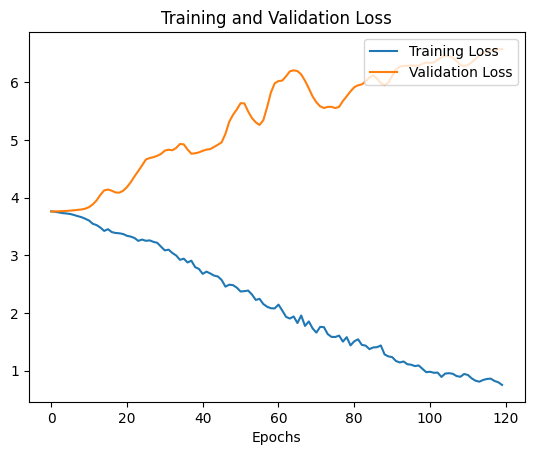

In [30]:
import matplotlib.pyplot as plt
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.legend(loc = 'upper right')
plt.show()   
